### Air Pollution
Refine objectives: 
- Build and compare classical statistical models, machine learning and deep learning models to forecast PM2.5 concentrations in Cambodia.
- To integrate environmental and meteorological features (e.g., temperature, humidity, wind speed) into the prediction models to enhance time-series forecasting accuracy.

Multivariate time-series analysis

- To assess the contribution of AI-driven air quality forecasting to Sustainable Development Goals—particularly SDG 3 (Good Health), SDG 11 (Sustainable Cities), and SDG 13 (Climate Action)—by enabling data-driven mitigation strategies.

To improve models: Consider
- Hybrid; SARIMA + LSTM or XBGoost + LSTM
- Fine-tuning hypermeters
Try Exponential Smoothing
Aggregate data in hourly
3h, 6h

Try Moving Average (Use to merge data into 3h and 6h)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
import statistics

In [3]:
missing_value = ['N/a','na','nan',np.nan]
df1 = pd.read_csv('data/pm_weatherdata.csv', na_values=missing_value)
print(df1.isnull().sum())
# Drop any Nan values
df1 = df1.dropna()

display(df1[0:4])

id_sensor             0
pm1                   0
pm10                  0
pm25                  0
temperature           0
humidity              0
winddirection         0
direction             0
winddirection_volt    0
windspeed             0
windspeed_volt        0
Date                  0
dtype: int64


,id_sensor,pm1,pm10,pm25,temperature,humidity,winddirection,direction,winddirection_volt,windspeed,windspeed_volt,Date
0,252,7,21,20,30.4,81,360,North,20.01,10,1.78,2024-02-15 18:07:40
1,253,7,16,13,29.9,83,360,North,20.01,4,0.70,2024-02-15 18:37:37
2,254,5,15,14,29.7,86,360,North,20.01,14,2.44,2024-02-15 19:07:37
3,255,5,12,10,29.6,85,360,North,20.01,9,1.59,2024-02-15 19:37:37


In [4]:
# Feature Engineering
df1['Date'] = pd.to_datetime(df1['Date'])
df1['Year'] = df1['Date'].dt.year
df1['Month'] = df1['Date'].dt.month
df1['Day'] = df1['Date'].dt.day
df1['Hour'] = df1['Date'].dt.hour
df1['Minute'] = df1['Date'].dt.minute
# df1['DayOfWeek'] = df1['Date'].dt.dayofweek
# df1['DayOfYear'] = df1['Date'].dt.dayofyear
# df1['WeekOfYear'] = df1['Date'].dt.isocalendar().week
# df1['WeekOfYear'] = df1['WeekOfYear'].astype(int)
# df1['IsWeekend'] = df1['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

In [5]:
df1['datetime'] = pd.to_datetime(df1[['Year', 'Month', 'Day', 'Hour', 'Minute']])
df1.set_index('datetime', inplace=True)
df1 = df1.drop(columns=['Date', 'direction'])
# df1 = df1.drop(columns=['Date', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'direction'])

In [6]:
# Use rolling + resample (moving average)
df_hourly = df1.resample('1H').mean()
df_hourly = df_hourly.dropna()
display(df_hourly[0:4])

/var/folders/z6/2wz7jxb56936gt0mxv3lscnm0000gn/T/ipykernel_35461/1022081966.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df1.resample('1H').mean()


,id_sensor,pm1,pm10,pm25,temperature,humidity,winddirection,winddirection_volt,windspeed,windspeed_volt,Year,Month,Day,Hour,Minute
datetime,,,,,,,,,,,,,,,
2024-02-15 18:00:00,252.5,7.0,18.5,16.5,30.15,82.0,360.0,20.01,7.0,1.240,2024.0,2.0,15.0,18.0,22.0
2024-02-15 19:00:00,254.5,5.0,13.5,12.0,29.65,85.5,360.0,20.01,11.5,2.015,2024.0,2.0,15.0,19.0,22.0
2024-02-15 20:00:00,256.5,4.5,13.5,11.0,29.60,85.0,360.0,20.01,6.0,1.105,2024.0,2.0,15.0,20.0,22.0
2024-02-15 21:00:00,258.5,7.0,15.5,15.5,29.55,86.5,360.0,20.01,2.0,0.335,2024.0,2.0,15.0,21.0,22.0


In [7]:
# Map Direction name to their index in the list
# display(df1['direction'].unique())
# direction_list = ['North', 'West', 'Unknown', 'Southwest', 'Northwest', 'South',
#        'Northeast', 'East', 'Southeast']
# df1['direction'] = df1['direction'].map(lambda x: direction_list.index(x) if x in direction_list else -1)
# display(df1[0:4])

In [8]:
# 'Year', 'Month', 'Day', 'Hour', 
features = ['Year', 'Month', 'Day', 'Hour', 'temperature', 'humidity', 'winddirection', 'winddirection_volt', 'windspeed']
# targets = ['pm1', 'pm10', 'pm25']
target = 'pm25'
X = df1[features]
y = df1[target]
display(X[0:4])

,Year,Month,Day,Hour,temperature,humidity,winddirection,winddirection_volt,windspeed
datetime,,,,,,,,,
2024-02-15 18:07:00,2024,2,15,18,30.4,81,360,20.01,10
2024-02-15 18:37:00,2024,2,15,18,29.9,83,360,20.01,4
2024-02-15 19:07:00,2024,2,15,19,29.7,86,360,20.01,14
2024-02-15 19:37:00,2024,2,15,19,29.6,85,360,20.01,9


### ARIMA

datetime
2024-02-15 18:00:00    16.5
2024-02-15 19:00:00    12.0
2024-02-15 20:00:00    11.0
2024-02-15 21:00:00    15.5
Name: pm25, dtype: float64

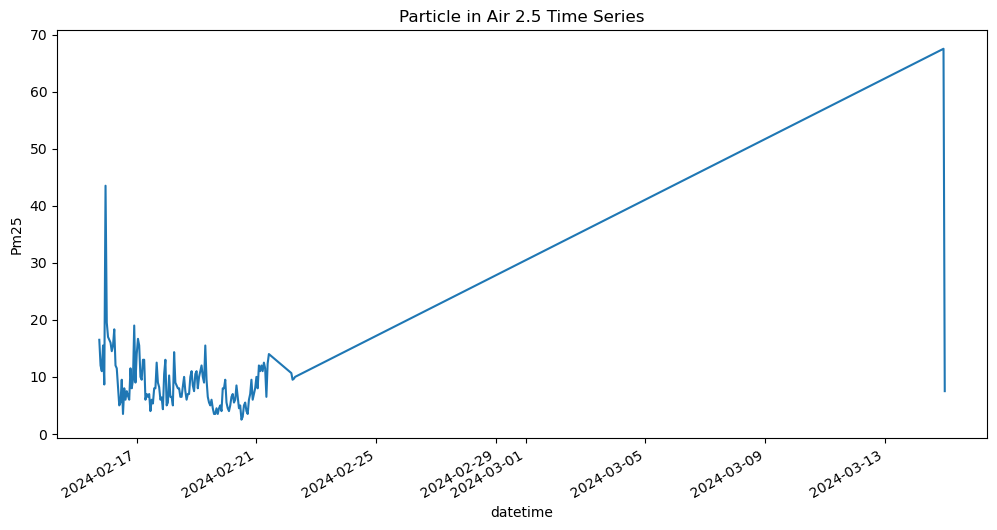

ADF Statistic: -2.5736195585158934
p-value: 0.09857305877688799


/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction resul

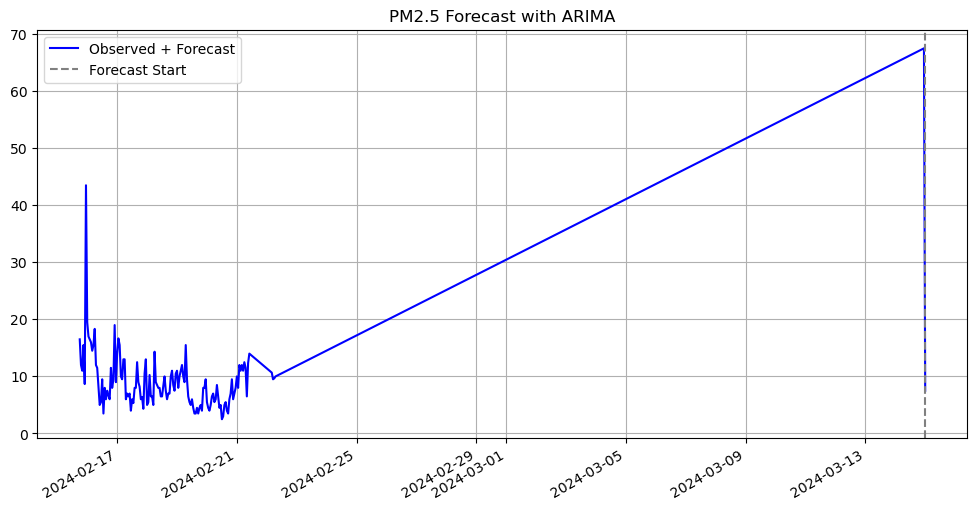

In [18]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Keep only the targe variable
ts = df_hourly[target].astype('float')
# ts = ts.index(-1)  # Ensure the index is datetime
display(ts[0:4])
# Visualize the time series
ts.plot(title='Particle in Air 2.5 Time Series', figsize=(12, 6))
plt.ylabel('Pm25')
plt.show()

# Check stationarity (ADF test)
result = adfuller(ts.dropna())
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}') # If p-value > 0.05 → non-stationary; differencing might be needed

# difference the time series if needed
ts_diff = ts.diff().dropna()

# (p, d, q) values can be determined using ACF and PACF or auto_arima
model = ARIMA(ts, order=(1,1,1))
model_fit = model.fit()
forecast_values = model_fit.forecast(steps=24)

# Set proper datetime index
last_date = ts.index[-1]
forecast_index = pd.date_range(start=last_date + pd.Timedelta(hours=1), periods=24, freq='h')
forecast = pd.Series(forecast_values, index=forecast_index)

ts_extended = pd.concat([ts, forecast])
ts_extended.plot(figsize=(12, 6), label='Observed + Forecast', color='blue')
plt.axvline(x=ts.index[-1], color='gray', linestyle='--', label='Forecast Start')
plt.legend()
plt.title('PM2.5 Forecast with ARIMA')
plt.grid(True)
plt.show()

### SARIMA + LSTM Hybrid Pipeline
Workflow:
1. Preprocess and smooth data (hourly with moving average)
2. Fit SARIMA model
3. Compute residuals: residual = actual - SARIMA prediction
4. Train LSTM on residuals
5. Forecast future: SARIMA + LSTM
6. Plot hybrid forecast

#### Prepare data (assuming df_hourly is ready)

In [19]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Select target (e.g., pm25)
target_col = 'pm25'
ts = df_hourly[target_col].dropna().astype(float)

2025-05-27 21:57:33.541568: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [20]:
# Fit SARIMA and get residuals
# Fit SARIMA (adjust seasonal_order if your data has seasonality, like daily = 24 hours)
sarima_model = SARIMAX(ts, order=(1,1,1), seasonal_order=(1,1,1,24))
sarima_fit = sarima_model.fit(disp=False)

# Get in-sample prediction and residuals
sarima_pred = sarima_fit.fittedvalues
residuals = ts - sarima_pred

/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [21]:
# Prepare residuals for LSTM
# Scale residuals
scaler = MinMaxScaler()
residual_scaled = scaler.fit_transform(residuals.dropna().values.reshape(-1, 1))

# Create sequences
def create_sequences(data, lookback=24):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])
    return np.array(X), np.array(y)

lookback = 24
X_lstm, y_lstm = create_sequences(residual_scaled, lookback)


In [23]:
# Train LSTM on residuals
model = Sequential()
model.add(LSTM(64, input_shape=(lookback, 1), return_sequences=False))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
model.fit(X_lstm, y_lstm, epochs=20, batch_size=16, validation_split=0.1)


Epoch 1/20


/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.1088 - val_loss: 0.0616
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0101 - val_loss: 0.0375
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0111 - val_loss: 0.0372
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0040 - val_loss: 0.0414
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0049 - val_loss: 0.0364
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0028 - val_loss: 0.0340
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0053 - val_loss: 0.0348
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0037 - val_loss: 0.0365
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0044 - val_loss: 0.0355
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0029 - val_loss: 0.0351
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0034 - val_loss: 0.0353
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0035 - val_loss: 0.0353
Epoch 13/20


In [24]:
# Forecast with SARIMA (next 24 hours)
sarima_forecast = sarima_fit.forecast(steps=24)

# Use last known residuals for LSTM forecast
last_residuals = residual_scaled[-lookback:]
input_seq = last_residuals.copy()
lstm_preds = []

for _ in range(24):
    pred = model.predict(input_seq.reshape(1, lookback, 1), verbose=0)
    lstm_preds.append(pred[0, 0])
    input_seq = np.append(input_seq[1:], pred, axis=0)

# Inverse scale LSTM forecast
lstm_forecast = scaler.inverse_transform(np.array(lstm_preds).reshape(-1, 1)).flatten()

# Combine forecasts
hybrid_forecast = sarima_forecast.values + lstm_forecast

# Set time index
forecast_index = pd.date_range(start=ts.index[-1] + pd.Timedelta(hours=1), periods=24, freq='H')
hybrid_series = pd.Series(hybrid_forecast, index=forecast_index)


/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/var/folders/z6/2wz7jxb56936gt0mxv3lscnm0000gn/T/ipykernel_35461/3482748505.py:21: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  forecast_index = pd.date_range(start=ts.index[-1] + pd.Timedelta(hours=1), periods=24, freq='H')


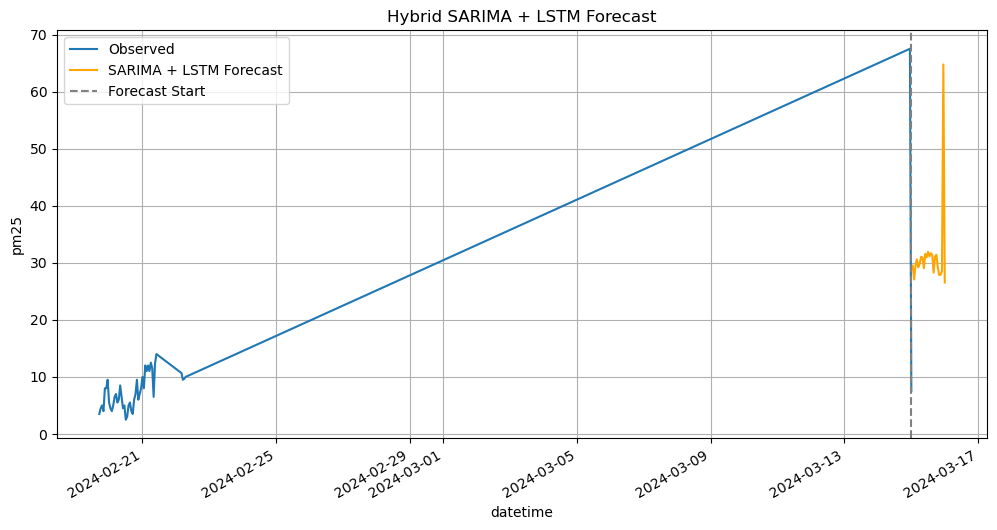

In [25]:
# Plot the hybrid forecast
plt.figure(figsize=(12, 6))
ts[-48:].plot(label='Observed')
hybrid_series.plot(label='SARIMA + LSTM Forecast', color='orange')
plt.axvline(x=ts.index[-1], color='gray', linestyle='--', label='Forecast Start')
plt.legend()
plt.title('Hybrid SARIMA + LSTM Forecast')
plt.ylabel(target_col)
plt.grid(True)
plt.show()


### Tune SARIMA Parametres Automatically (auto_arima)
Use pmdarima.auto_arima to find the best (p, d, q)(P, D, Q, s):

In [27]:
import pmdarima as pm

auto_model = pm.auto_arima(ts, seasonal=True, m=24, trace=True, stepwise=True)
print(auto_model.summary())

/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarni

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[24] intercept   : AIC=inf, Time=1.42 sec
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=956.120, Time=0.01 sec


/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=952.352, Time=0.42 sec


/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,0,3)(0,0,0)[24] intercept   : AIC=inf, Time=0.31 sec
 ARIMA(1,0,3)(0,0,0)[24] intercept   : AIC=938.932, Time=0.10 sec


/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,0,3)(0,0,0)[24] intercept   : AIC=941.049, Time=0.25 sec
 ARIMA(2,0,2)(0,0,0)[24]             : AIC=942.774, Time=0.09 sec

Best model:  ARIMA(2,0,2)(0,0,0)[24] intercept
Total fit time: 14.247 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  143
Model:               SARIMAX(2, 0, 2)   Log Likelihood                -462.533
Date:                Tue, 27 May 2025   AIC                            937.066
Time:                        22:17:56   BIC                            954.843
Sample:                             0   HQIC                           944.290
                                - 143                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [28]:
# Use Exogenous Variables (SARIMAX + LSTM)
exog_cols = ['temperature', 'humidity', 'winddirection']
exog = df_hourly[exog_cols].astype(float).dropna()

# Align `ts` and `exog`
ts = ts[ts.index.isin(exog.index)]
exog = exog[exog.index.isin(ts.index)]

# Fit SARIMAX with exog
model = SARIMAX(ts, exog=exog, order=(1,1,1), seasonal_order=(1,1,1,24))
sarima_fit = model.fit(disp=False)


/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/rattanak/miniconda3/envs/py312/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [30]:
import joblib
joblib.dump(sarima_fit, 'sarima_model.pkl')
sarima_fit = joblib.load('sarima_model.pkl')